In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

# Train/test split
train = df[df.index < '2025-07-13']
test = df[df.index >= '2025-07-13']

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({len(train)} días)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({len(test)} días)")

Train: 2013-01-01 → 2025-07-12 (4576 días)
Test:  2025-07-13 → 2026-05-01 (293 días)


In [2]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Revisar estacionariedad del train
resultado = adfuller(train['precio_bolsa'])
print(f"ADF p-valor: {resultado[1]:.4f}")
print(f"La serie {'ES' if resultado[1] < 0.05 else 'NO ES'} estacionaria")

ADF p-valor: 0.0002
La serie ES estacionaria


In [3]:
modelo = SARIMAX(
    train['precio_bolsa'],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado = modelo.fit(disp=False)
print(resultado.summary())

                                     SARIMAX Results                                     
Dep. Variable:                      precio_bolsa   No. Observations:                 4576
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -25332.826
Date:                           Mon, 13 Jul 2026   AIC                          50675.652
Time:                                   17:50:28   BIC                          50707.785
Sample:                               01-01-2013   HQIC                         50686.966
                                    - 07-12-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9726      0.001    939.731      0.000       0.971       0.975
ma.L1         -0.1711      0.002    -68.648

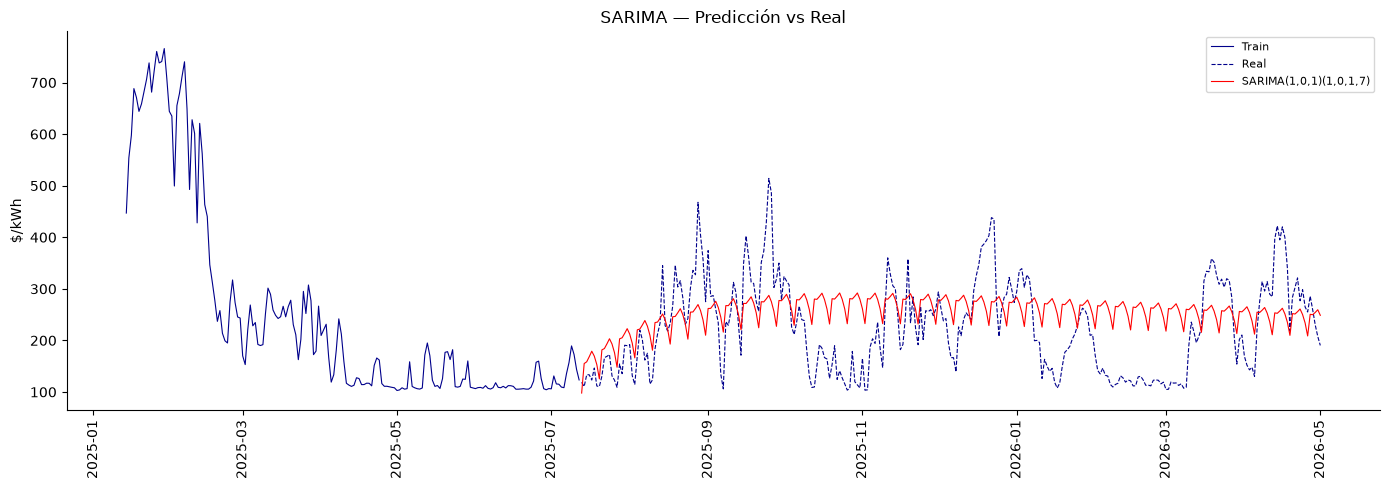

In [4]:
predicciones = resultado.forecast(steps=len(test))
predicciones.index = test.index

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, predicciones, color='red', linewidth=0.8, label='SARIMA(1,0,1)(1,0,1,7)')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('SARIMA — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

real = test['precio_bolsa']
pred = predicciones

mae = np.mean(np.abs(real - pred))
rmse = np.sqrt(np.mean((real - pred)**2))
mape = np.mean(np.abs((real - pred) / real)) * 100

print(f"MAE:  {mae:.2f} $/kWh")
print(f"RMSE: {rmse:.2f} $/kWh")
print(f"MAPE: {mape:.2f}%")
print(f"Precio promedio test: {real.mean():.2f} $/kWh")

MAE:  74.82 $/kWh
RMSE: 89.89 $/kWh
MAPE: 43.70%
Precio promedio test: 225.93 $/kWh


In [6]:
resultados = {
    'SARIMA(1,0,1)(1,0,1,7)': {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2)
    }
}

print(pd.DataFrame(resultados).T)

                          MAE   RMSE  MAPE
SARIMA(1,0,1)(1,0,1,7)  74.82  89.89  43.7


In [7]:
from itertools import product
import warnings
warnings.filterwarnings('ignore')

import time
inicio = time.time()

p_values = [0, 1, 2]
q_values = [0, 1, 2]
P_values = [0, 1]
Q_values = [0, 1]

combinaciones = list(product(p_values, q_values, P_values, Q_values))
print(f"Total combinaciones: {len(combinaciones)}")

resultados_grid = []

for i, (p, q, P, Q) in enumerate(combinaciones):
    try:
        modelo = SARIMAX(
            train['precio_bolsa'],
            order=(p, 0, q),
            seasonal_order=(P, 0, Q, 7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = modelo.fit(disp=False)
        resultados_grid.append({
            'p': p, 'q': q, 'P': P, 'Q': Q,
            'AIC': round(res.aic, 2),
            'BIC': round(res.bic, 2)
        })
        print(f"[{i+1}/{len(combinaciones)}] SARIMA({p},0,{q})({P},0,{Q},7) — AIC: {res.aic:.2f}")
    except Exception as e:
        print(f"[{i+1}/{len(combinaciones)}] SARIMA({p},0,{q})({P},0,{Q},7) — Error: {e}")

df_grid = pd.DataFrame(resultados_grid).sort_values('AIC')
print("\nTop 5 modelos por AIC:")
print(df_grid.head())
fin = time.time()
minutos = (fin - inicio) / 60
print(f"\nTiempo total: {minutos:.1f} minutos")

Total combinaciones: 36
[1/36] SARIMA(0,0,0)(0,0,0,7) — AIC: 67543.27
[2/36] SARIMA(0,0,0)(0,0,1,7) — AIC: 63314.51
[3/36] SARIMA(0,0,0)(1,0,0,7) — AIC: 57786.52
[4/36] SARIMA(0,0,0)(1,0,1,7) — AIC: 57739.06
[5/36] SARIMA(0,0,1)(0,0,0,7) — AIC: 62298.63
[6/36] SARIMA(0,0,1)(0,0,1,7) — AIC: 59460.28
[7/36] SARIMA(0,0,1)(1,0,0,7) — AIC: 55127.30
[8/36] SARIMA(0,0,1)(1,0,1,7) — AIC: 54823.17
[9/36] SARIMA(0,0,2)(0,0,0,7) — AIC: 58806.88
[10/36] SARIMA(0,0,2)(0,0,1,7) — AIC: 56896.16
[11/36] SARIMA(0,0,2)(1,0,0,7) — AIC: 54078.68
[12/36] SARIMA(0,0,2)(1,0,1,7) — AIC: 53470.81
[13/36] SARIMA(1,0,0)(0,0,0,7) — AIC: 51126.36
[14/36] SARIMA(1,0,0)(0,0,1,7) — AIC: 51005.36
[15/36] SARIMA(1,0,0)(1,0,0,7) — AIC: 50997.54
[16/36] SARIMA(1,0,0)(1,0,1,7) — AIC: 50789.86
[17/36] SARIMA(1,0,1)(0,0,0,7) — AIC: 50974.52
[18/36] SARIMA(1,0,1)(0,0,1,7) — AIC: 50863.21
[19/36] SARIMA(1,0,1)(1,0,0,7) — AIC: 50867.24
[20/36] SARIMA(1,0,1)(1,0,1,7) — AIC: 50675.65
[21/36] SARIMA(1,0,2)(0,0,0,7) — AIC: 50948.5

In [8]:
mejor = df_grid.iloc[0]
print(f"Mejor modelo: SARIMA({int(mejor.p)},0,{int(mejor.q)})({int(mejor.P)},0,{int(mejor.Q)},7)")

modelo_optimo = SARIMAX(
    train['precio_bolsa'],
    order=(int(mejor.p), 0, int(mejor.q)),
    seasonal_order=(int(mejor.P), 0, int(mejor.Q), 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_optimo = modelo_optimo.fit(disp=False)

pred_optimo = resultado_optimo.forecast(steps=len(test))
pred_optimo.index = test.index

mae_opt = np.mean(np.abs(real - pred_optimo))
rmse_opt = np.sqrt(np.mean((real - pred_optimo)**2))
mape_opt = np.mean(np.abs((real - pred_optimo) / real)) * 100

print(f"\nMAE:  {mae_opt:.2f} $/kWh")
print(f"RMSE: {rmse_opt:.2f} $/kWh")
print(f"MAPE: {mape_opt:.2f}%")

Mejor modelo: SARIMA(2,0,2)(1,0,1,7)

MAE:  72.85 $/kWh
RMSE: 87.72 $/kWh
MAPE: 41.42%


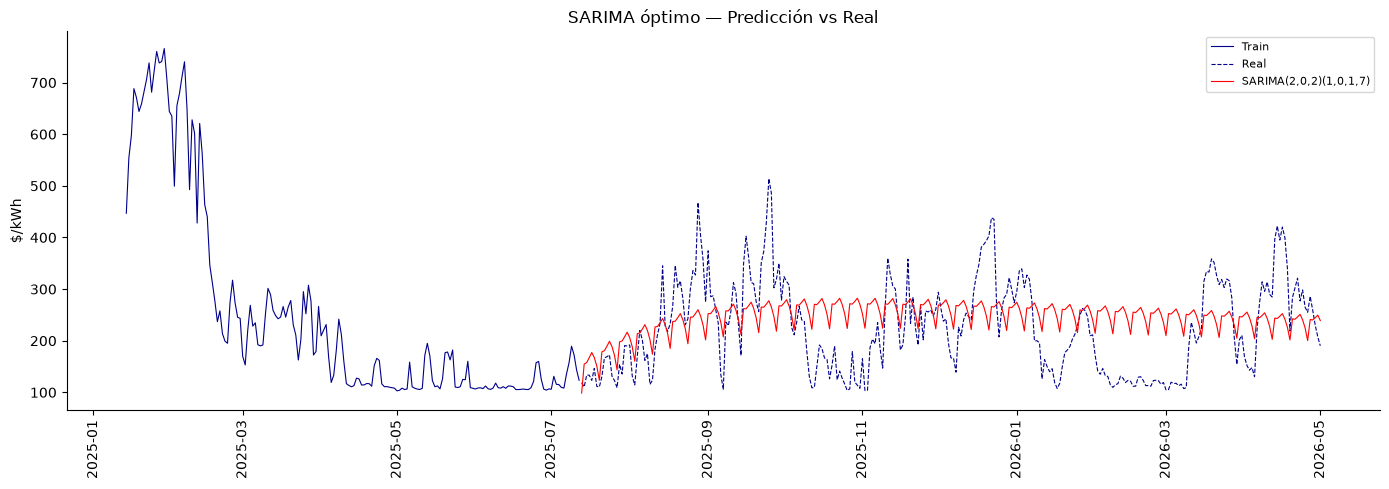

                          MAE   RMSE   MAPE
SARIMA(1,0,1)(1,0,1,7)  74.82  89.89  43.70
SARIMA(2,0,2)(1,0,1,7)  72.85  87.72  41.42


In [9]:
resultados['SARIMA(2,0,2)(1,0,1,7)'] = {
    'MAE': round(mae_opt, 2),
    'RMSE': round(rmse_opt, 2),
    'MAPE': round(mape_opt, 2)
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_optimo, color='red', linewidth=0.8, label='SARIMA(2,0,2)(1,0,1,7)')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('SARIMA óptimo — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

print(pd.DataFrame(resultados).T)

Ahora con covariables en test

In [10]:
covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']

modelo_sarimax = SARIMAX(
    train['precio_bolsa'],
    exog=train[covariables],
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarimax = modelo_sarimax.fit(disp=False)
print(resultado_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        precio_bolsa   No. Observations:                 4576
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 7)   Log Likelihood              -26068.259
Date:                             Mon, 13 Jul 2026   AIC                          52156.518
Time:                                     17:59:30   BIC                          52220.782
Sample:                                 01-01-2013   HQIC                         52179.145
                                      - 07-12-2025                                         
Covariance Type:                               opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
gen_termica          7.264e-06   5.65e-08    128.672      0.000    7.15e-06    7.37e-06


MAE:  69.10 $/kWh
RMSE: 83.42 $/kWh
MAPE: 29.85%


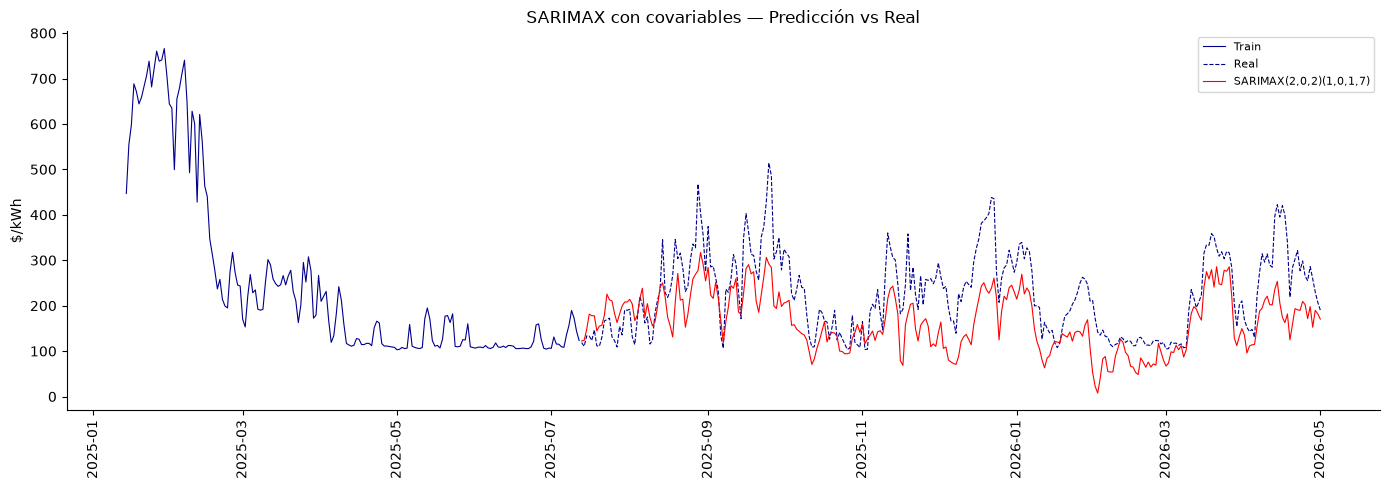

                           MAE   RMSE   MAPE
SARIMA(1,0,1)(1,0,1,7)   74.82  89.89  43.70
SARIMA(2,0,2)(1,0,1,7)   72.85  87.72  41.42
SARIMAX(2,0,2)(1,0,1,7)  69.10  83.42  29.85


In [11]:
pred_sarimax = resultado_sarimax.forecast(steps=len(test), exog=test[covariables])
pred_sarimax.index = test.index

mae_sarimax = np.mean(np.abs(real - pred_sarimax))
rmse_sarimax = np.sqrt(np.mean((real - pred_sarimax)**2))
mape_sarimax = np.mean(np.abs((real - pred_sarimax) / real)) * 100

print(f"MAE:  {mae_sarimax:.2f} $/kWh")
print(f"RMSE: {rmse_sarimax:.2f} $/kWh")
print(f"MAPE: {mape_sarimax:.2f}%")

resultados['SARIMAX(2,0,2)(1,0,1,7)'] = {
    'MAE': round(mae_sarimax, 2),
    'RMSE': round(rmse_sarimax, 2),
    'MAPE': round(mape_sarimax, 2)
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index[-180:], train['precio_bolsa'][-180:], color='darkblue', linewidth=0.8, label='Train')
ax.plot(test.index, test['precio_bolsa'], color='darkblue', linewidth=0.8, linestyle='--', label='Real')
ax.plot(test.index, pred_sarimax, color='red', linewidth=0.8, label='SARIMAX(2,0,2)(1,0,1,7)')
ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('SARIMAX con covariables — Predicción vs Real')
sns.despine()
plt.tight_layout()
plt.show()

print(pd.DataFrame(resultados).T)